# 1. Feature Engineering

Convert raw YOLO Pose keypoints into a **rich biomechanical feature vector** for every frame.

```
Keypoints (x, y, conf) ×17
   ↓
Angles  (elbow L/R, hip L/R, shoulder-ankle alignment)
   ↓
Velocities  (Δangle, Δheight per frame)
   ↓
Body signals  (straightness, symmetry, center height)
   ↓
Feature vector  F = 15  →  saved as per-video JSON
```

### Feature vector (15 dims)
| # | Feature | Why it matters |
|---|---|---|
| 0 | `left_elbow_angle` | primary rep signal |
| 1 | `right_elbow_angle` | primary rep signal |
| 2 | `mean_elbow_angle` | averaged robust signal |
| 3 | `elbow_symmetry` | elbow flare detection |
| 4 | `left_hip_angle` | hip sag detection |
| 5 | `right_hip_angle` | hip sag detection |
| 6 | `body_straightness` | alignment quality |
| 7 | `shoulder_height_norm` | vertical position |
| 8 | `hip_height_norm` | vertical position |
| 9 | `shoulder_velocity` | Δshoulder_height/frame |
| 10 | `hip_velocity` | Δhip_height/frame |
| 11 | `elbow_angle_velocity` | Δmean_elbow/frame |
| 12 | `wrist_width_norm` | hand placement |
| 13 | `shoulder_width_norm` | scale reference |
| 14 | `nose_height_norm` | head position |

**Depends on:** `keypoint_detector/` notebook 2 — keypoint JSONs in `keypoint_detector/data/keypoints/`

In [13]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['numpy', 'pandas', 'matplotlib', 'scipy', 'tqdm']:
    install(pkg)
print('Dependencies ready.')

Dependencies ready.


In [14]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT     = Path('..').resolve()
KD_DIR   = ROOT / 'keypoint_detector'
FE_DIR   = ROOT / 'feature_engineering'
FEAT_DIR = FE_DIR / 'data' / 'features'
FEAT_DIR.mkdir(parents=True, exist_ok=True)

# Load the best model choice from keypoint_detector
choice_path = KD_DIR / 'best_model_choice.json'
if not choice_path.exists():
    raise FileNotFoundError('Run keypoint_detector notebooks 2-3 first.')

choice   = json.loads(choice_path.read_text())
MODEL_ID = choice['model_id'].replace('.pt', '')   # e.g. 'yolo11m-pose'
KPS_DIR  = KD_DIR / 'data' / 'keypoints' / MODEL_ID

print(f'Using model  : {MODEL_ID}')
print(f'Keypoints dir: {KPS_DIR}')

kps_files = sorted(KPS_DIR.glob('*.json'))
print(f'Video files  : {len(kps_files)}')

if not kps_files:
    raise FileNotFoundError(f'No keypoint files in {KPS_DIR}')

Using model  : yolov8n-pose
Keypoints dir: /Users/haleytran/Downloads/pushup_judge/keypoint_detector/data/keypoints/yolov8n-pose
Video files  : 152


## 1.1 Angle + Geometry Helpers

In [15]:
def angle_3pts(a, b, c):
    """Angle (degrees) at vertex b formed by rays b→a and b→c."""
    ba = np.asarray(a, float) - np.asarray(b, float)
    bc = np.asarray(c, float) - np.asarray(b, float)
    n  = np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-9
    return float(np.degrees(np.arccos(np.clip(np.dot(ba, bc) / n, -1, 1))))


def perpendicular_dist(p, line_a, line_b):
    """
    Perpendicular distance of point p from the line defined by line_a → line_b.
    All inputs are (2,) arrays.
    """
    ab = line_b - line_a
    t  = np.dot(p - line_a, ab) / (np.dot(ab, ab) + 1e-9)
    proj = line_a + t * ab
    return float(np.linalg.norm(p - proj))


def euclidean(a, b):
    return float(np.linalg.norm(np.asarray(a) - np.asarray(b)))


print('Geometry helpers ready.')

Geometry helpers ready.


## 1.2 Full Feature Extraction — One Frame

In [16]:
CONF_THRESH = 0.3

# Feature vector column order (F = 15)
FEATURE_COLS = [
    'left_elbow_angle',     # 0
    'right_elbow_angle',    # 1
    'mean_elbow_angle',     # 2  ← primary rep-segmentation signal
    'elbow_symmetry',       # 3
    'left_hip_angle',       # 4
    'right_hip_angle',      # 5
    'body_straightness',    # 6
    'shoulder_height_norm', # 7
    'hip_height_norm',      # 8
    'shoulder_velocity',    # 9   filled in per-sequence step
    'hip_velocity',         # 10  filled in per-sequence step
    'elbow_angle_velocity', # 11  filled in per-sequence step
    'wrist_width_norm',     # 12
    'shoulder_width_norm',  # 13
    'nose_height_norm',     # 14
]

NAN_FRAME = {col: np.nan for col in FEATURE_COLS}


def extract_frame_features(kps: np.ndarray, img_h: int, img_w: int,
                           conf: float = CONF_THRESH) -> dict:
    """
    kps: (17, 3)  [x_px, y_px, confidence]
    Returns dict of static features (velocities filled later).
    Positions normalised by image dimensions.
    """
    H, W = float(img_h), float(img_w)

    def pt(i):
        """Return normalised (x,y) if confidence OK, else None."""
        if kps[i, 2] > conf:
            return np.array([kps[i,0]/W, kps[i,1]/H])
        return None

    nose   = pt(0)
    l_sh   = pt(5);  r_sh = pt(6)
    l_el   = pt(7);  r_el = pt(8)
    l_wr   = pt(9);  r_wr = pt(10)
    l_hi   = pt(11); r_hi = pt(12)
    l_kn   = pt(13); r_kn = pt(14)
    l_an   = pt(15); r_an = pt(16)

    d = dict(NAN_FRAME)   # start with all NaN

    # ── Elbow angles ─────────────────────────────────────────────────────────
    if l_sh is not None and l_el is not None and l_wr is not None:
        d['left_elbow_angle']  = angle_3pts(l_sh, l_el, l_wr)
    if r_sh is not None and r_el is not None and r_wr is not None:
        d['right_elbow_angle'] = angle_3pts(r_sh, r_el, r_wr)

    vals = [v for v in [d['left_elbow_angle'], d['right_elbow_angle']]
            if not np.isnan(v)]
    d['mean_elbow_angle'] = float(np.mean(vals)) if vals else np.nan
    if not np.isnan(d['left_elbow_angle']) and not np.isnan(d['right_elbow_angle']):
        d['elbow_symmetry'] = abs(d['left_elbow_angle'] - d['right_elbow_angle'])

    # ── Hip angles ───────────────────────────────────────────────────────────
    if l_sh is not None and l_hi is not None and l_kn is not None:
        d['left_hip_angle']  = angle_3pts(l_sh, l_hi, l_kn)
    if r_sh is not None and r_hi is not None and r_kn is not None:
        d['right_hip_angle'] = angle_3pts(r_sh, r_hi, r_kn)

    # ── Body straightness: hip deviation from shoulder-ankle line ────────────
    # Use whichever side has all three joints visible
    for sh, hi, an in [(l_sh, l_hi, l_an), (r_sh, r_hi, r_an)]:
        if sh is not None and hi is not None and an is not None:
            d['body_straightness'] = perpendicular_dist(hi, sh, an)
            break

    # ── Heights (normalised y; 0 = top of image) ─────────────────────────────
    sh_pts = [v for v in [l_sh, r_sh] if v is not None]
    hi_pts = [v for v in [l_hi, r_hi] if v is not None]
    if sh_pts:
        d['shoulder_height_norm'] = float(np.mean([p[1] for p in sh_pts]))
    if hi_pts:
        d['hip_height_norm']      = float(np.mean([p[1] for p in hi_pts]))

    # ── Widths (normalised by image width) ───────────────────────────────────
    if l_wr is not None and r_wr is not None:
        d['wrist_width_norm']    = euclidean(l_wr, r_wr)
    if l_sh is not None and r_sh is not None:
        d['shoulder_width_norm'] = euclidean(l_sh, r_sh)

    # ── Nose height ──────────────────────────────────────────────────────────
    if nose is not None:
        d['nose_height_norm'] = float(nose[1])

    return d


print('extract_frame_features() ready.')
print(f'Feature vector size: F = {len(FEATURE_COLS)}')
print('Columns:', FEATURE_COLS)

extract_frame_features() ready.
Feature vector size: F = 15
Columns: ['left_elbow_angle', 'right_elbow_angle', 'mean_elbow_angle', 'elbow_symmetry', 'left_hip_angle', 'right_hip_angle', 'body_straightness', 'shoulder_height_norm', 'hip_height_norm', 'shoulder_velocity', 'hip_velocity', 'elbow_angle_velocity', 'wrist_width_norm', 'shoulder_width_norm', 'nose_height_norm']


## 1.3 Velocity Computation

Velocities are **temporal derivatives** — they cannot be computed per-frame in isolation.  
They are computed after all frames in a sequence are extracted.

In [17]:
def add_velocities(feat_seq: list[dict]) -> list[dict]:
    """
    feat_seq: list of per-frame feature dicts (same video).
    Mutates each dict in-place, adding velocity features.
    Frame 0 gets velocity = 0.
    """
    n = len(feat_seq)
    for i in range(n):
        prev = feat_seq[i-1] if i > 0 else feat_seq[i]
        cur  = feat_seq[i]

        def delta(key):
            v_cur  = cur.get(key,  np.nan)
            v_prev = prev.get(key, np.nan)
            if np.isnan(v_cur) or np.isnan(v_prev): return np.nan
            return float(v_cur - v_prev)

        cur['shoulder_velocity']    = delta('shoulder_height_norm')
        cur['hip_velocity']         = delta('hip_height_norm')
        cur['elbow_angle_velocity'] = delta('mean_elbow_angle')

    # Frame 0 velocity = 0 (not NaN — avoids downstream issues)
    for key in ['shoulder_velocity', 'hip_velocity', 'elbow_angle_velocity']:
        if np.isnan(feat_seq[0].get(key, np.nan)):
            feat_seq[0][key] = 0.0

    return feat_seq


print('add_velocities() ready.')

add_velocities() ready.


## 1.4 NaN Imputation

Keypoints can be invisible for a few frames.  
Strategy: **forward-fill then backward-fill** (propagate last known good value).  
Remaining NaN (start of sequence) → filled with column median.

In [18]:
def impute_sequence(feat_seq: list[dict]) -> list[dict]:
    """
    Forward-fill then backward-fill NaNs across the sequence.
    Remaining NaN filled with column median.
    """
    if not feat_seq:
        return feat_seq

    df = pd.DataFrame(feat_seq)[FEATURE_COLS]
    df = df.ffill().bfill()

    # Any still-NaN column (whole sequence invisible) → median or 0
    for col in df.columns:
        if df[col].isna().any():
            median = df[col].median()
            df[col] = df[col].fillna(median if not np.isnan(median) else 0.0)

    # Write back into list of dicts
    for i, row in enumerate(df.itertuples(index=False)):
        for col, val in zip(FEATURE_COLS, row):
            feat_seq[i][col] = float(val)

    return feat_seq


print('impute_sequence() ready.')

impute_sequence() ready.


## 1.5 Process All Videos

In [19]:
def process_video_kps(kps_json_path: Path) -> dict:
    """
    Load a keypoint JSON (from keypoint_detector), compute the feature vector
    for each frame, add velocities, impute NaN.

    Returns dict:
        {
            'video': str,
            'label': str,
            'features': [ {col: val, ...}, ... ]   # one dict per frame
            'mean_elbow_angle': [ float, ... ]      # extracted for quick access
        }
    """
    raw = json.loads(kps_json_path.read_text())
    label = raw[0]['label'] if raw else 'unknown'

    feat_seq = []
    for rec in raw:
        if rec['keypoints'] is None:
            feat_seq.append(dict(NAN_FRAME))
            continue
        kps = np.array(rec['keypoints'])   # (17, 3)
        h, w = rec['h'], rec['w']
        feat_seq.append(extract_frame_features(kps, h, w))

    feat_seq = add_velocities(feat_seq)
    feat_seq = impute_sequence(feat_seq)

    mean_elbow = [f['mean_elbow_angle'] for f in feat_seq]

    return {
        'video'           : kps_json_path.stem,
        'label'           : label,
        'features'        : feat_seq,
        'mean_elbow_angle': mean_elbow,
    }


print('process_video_kps() ready.')

process_video_kps() ready.


In [20]:
# ── Run on all videos (with caching) ─────────────────────────────────────────
results = []
skipped = 0

for jf in tqdm(kps_files, desc='Feature extraction'):
    out_path = FEAT_DIR / f'{jf.stem}.json'
    if out_path.exists():
        skipped += 1
        video_data = json.loads(out_path.read_text())
    else:
        video_data = process_video_kps(jf)
        # Serialise (convert numpy floats → Python floats)
        out_path.write_text(json.dumps(video_data))

    results.append({
        'video' : video_data['video'],
        'label' : video_data['label'],
        'frames': len(video_data['features']),
    })

df_summary = pd.DataFrame(results)
print(f'\nProcessed  : {len(results) - skipped} new  |  {skipped} cached')
print(f'Total videos: {len(results)}')
print(df_summary.groupby('label')['frames'].describe().round(1))

Feature extraction: 100%|██████████| 152/152 [00:00<00:00, 3887.36it/s]


Processed  : 0 new  |  152 cached
Total videos: 152
         count  mean  std  min  25%   50%   75%   max
label                                                
correct   76.0  10.7  3.8  6.0  8.0  10.0  12.0  20.0
wrong     76.0  13.8  7.0  6.0  9.0  12.0  14.2  30.0


## 1.6 Sanity Check — One Video

In [21]:
# Load a correct + wrong example
correct_files = [f for f in sorted(FEAT_DIR.glob('*.json'))
                 if json.loads((FEAT_DIR/f.name).read_text())['label'] == 'correct']
wrong_files   = [f for f in sorted(FEAT_DIR.glob('*.json'))
                 if json.loads((FEAT_DIR/f.name).read_text())['label'] == 'wrong']

ex_correct = json.loads(correct_files[0].read_text()) if correct_files else None
ex_wrong   = json.loads(wrong_files[0].read_text())   if wrong_files   else None

print(f'Correct example: {ex_correct["video"]} — {len(ex_correct["features"])} frames')
print(f'Wrong example  : {ex_wrong["video"]}   — {len(ex_wrong["features"])} frames')

# Show first frame features
print('\nFirst-frame feature vector (correct):')
df_row = pd.Series(ex_correct['features'][0])
print(df_row.round(4).to_string())

Correct example: Copy_of_push_up_1 — 8 frames
Wrong example  : 1   — 30 frames

First-frame feature vector (correct):
left_elbow_angle        165.0142
right_elbow_angle       165.4874
mean_elbow_angle        165.2508
elbow_symmetry            0.4732
left_hip_angle          113.6269
right_hip_angle         111.4767
body_straightness         0.1608
shoulder_height_norm      0.4922
hip_height_norm           0.4477
shoulder_velocity         0.0000
hip_velocity              0.0000
elbow_angle_velocity      0.0000
wrist_width_norm          0.0958
shoulder_width_norm       0.0591
nose_height_norm          0.5894


## 1.7 Feature Time-Series Visualisation

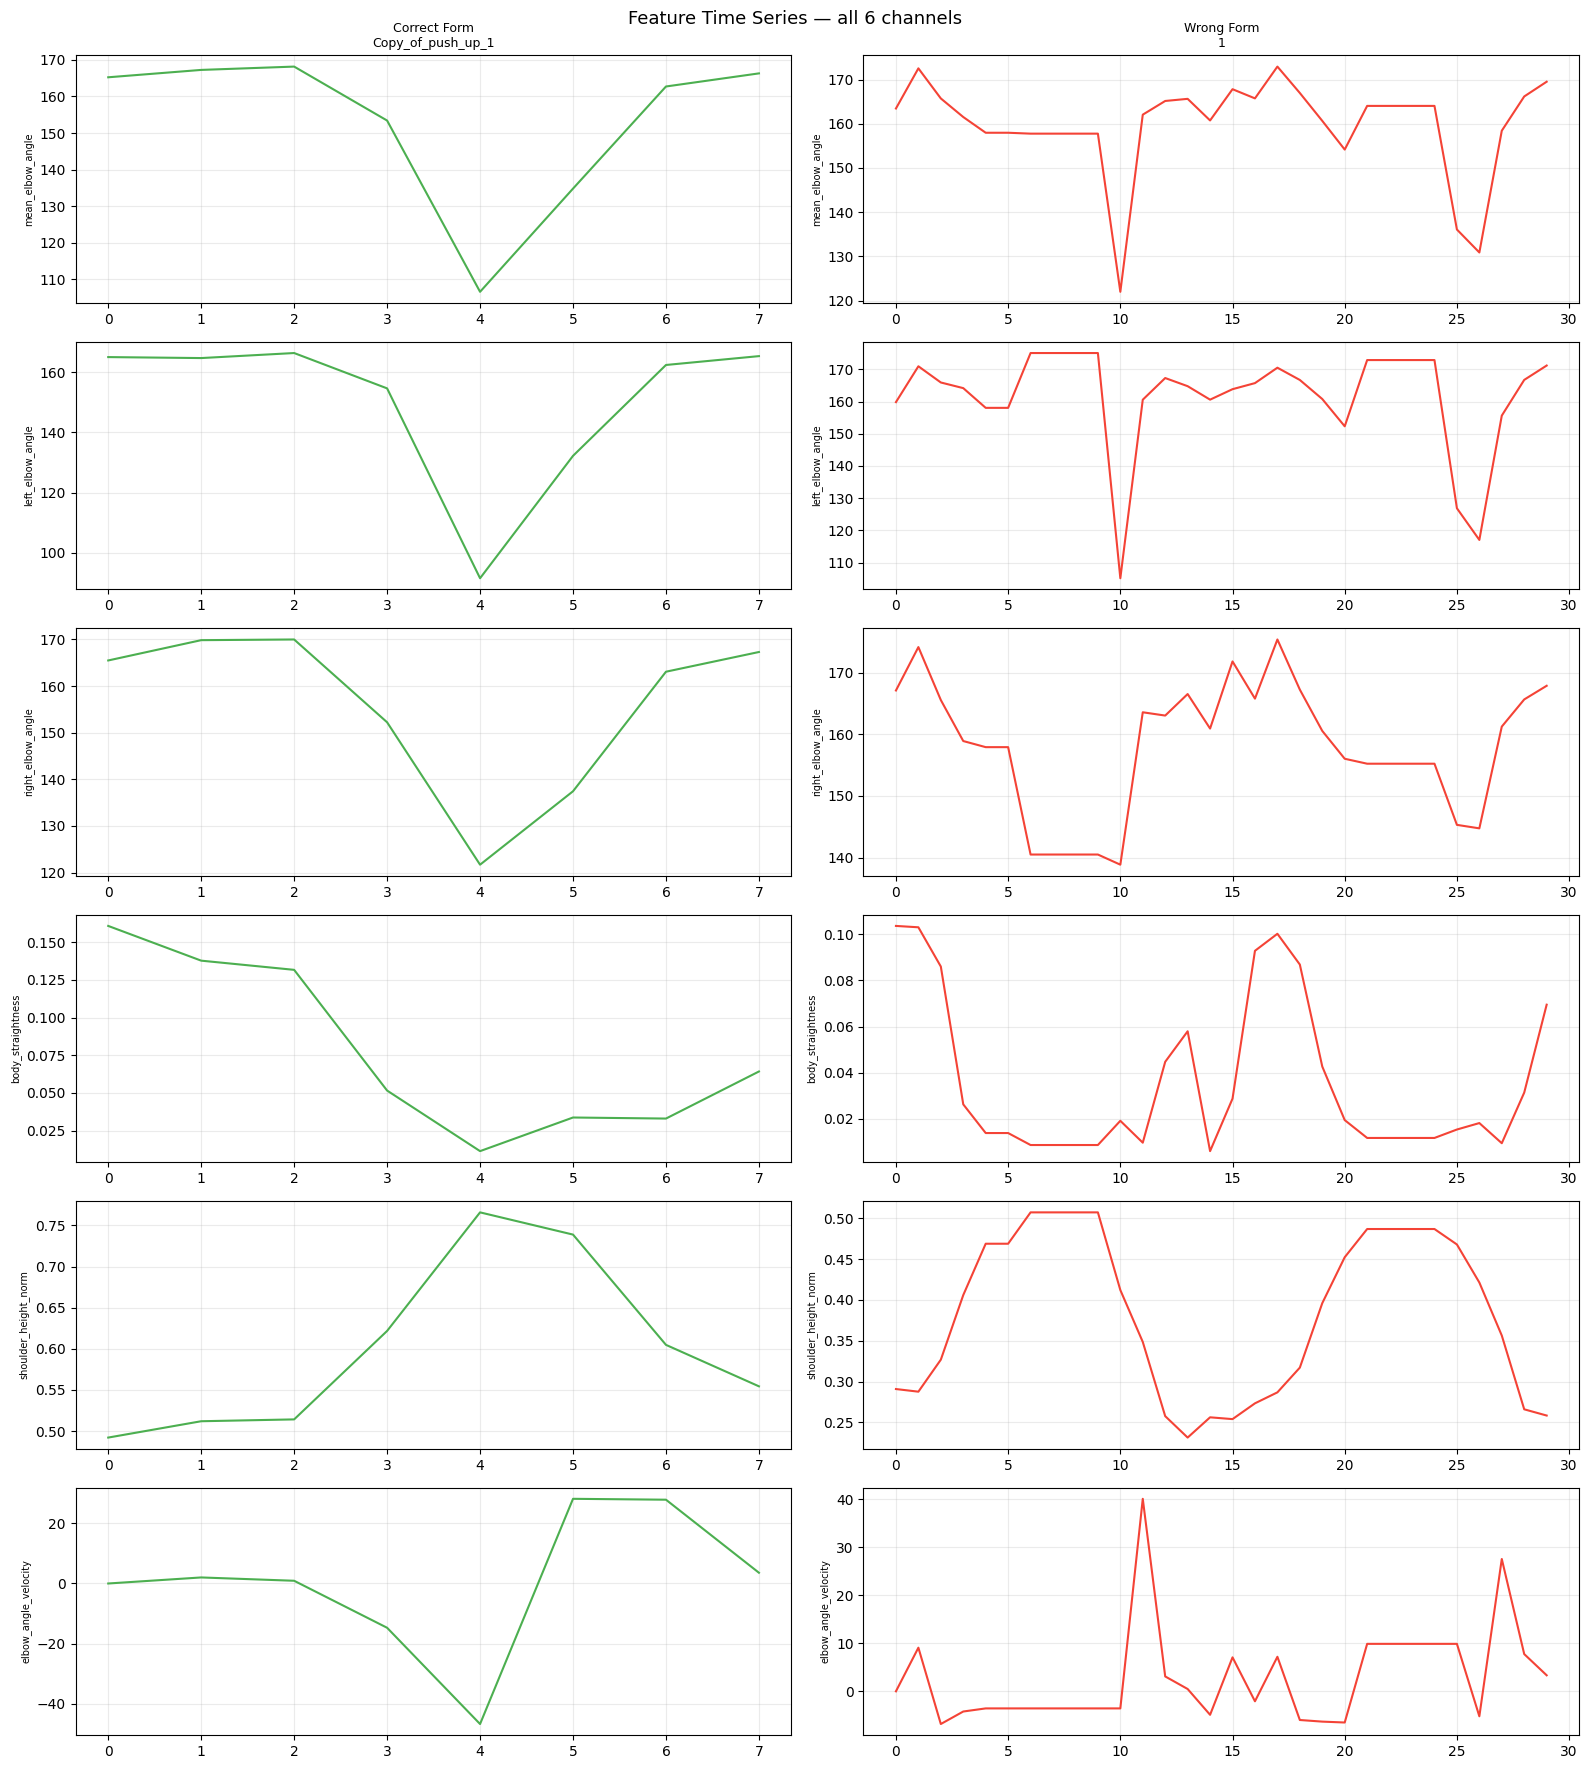

In [22]:
PLOT_COLS = [
    'mean_elbow_angle', 'left_elbow_angle', 'right_elbow_angle',
    'body_straightness', 'shoulder_height_norm', 'elbow_angle_velocity',
]

fig, axes = plt.subplots(len(PLOT_COLS), 2, figsize=(16, 3*len(PLOT_COLS)),
                         sharex=False)

for row, col in enumerate(PLOT_COLS):
    for col_idx, (ex, title_color) in enumerate([
        (ex_correct, ('#4CAF50', 'Correct Form')),
        (ex_wrong,   ('#F44336', 'Wrong Form')),
    ]):
        ax = axes[row][col_idx]
        if ex is None:
            ax.axis('off'); continue
        vals = [f[col] for f in ex['features']]
        t    = list(range(len(vals)))
        ax.plot(t, vals, color=title_color[0], lw=1.5)
        ax.set_ylabel(col, fontsize=7)
        ax.grid(alpha=0.25)
        if row == 0:
            ax.set_title(f'{title_color[1]}\n{ex["video"]}', fontsize=9)

fig.suptitle('Feature Time Series — all 6 channels', fontsize=13)
plt.tight_layout()
plt.show()

## 1.8 Feature Distributions — Correct vs Wrong

Total frame rows: 1858
label
correct     813
wrong      1045
dtype: int64


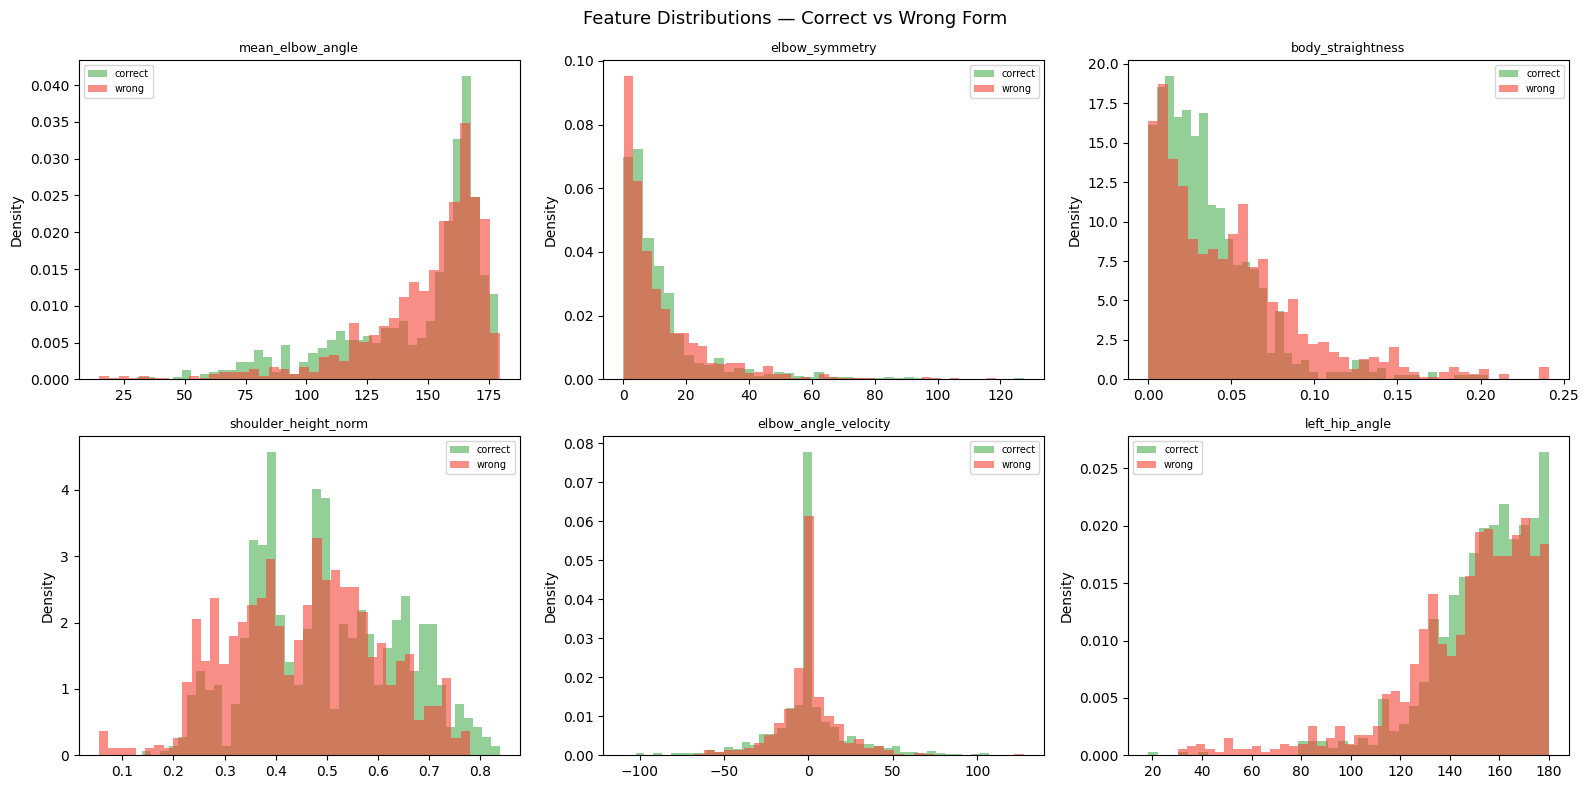

In [23]:
# Pool all frame feature values from all videos
all_rows = []
for jf in sorted(FEAT_DIR.glob('*.json')):
    vd = json.loads(jf.read_text())
    for f in vd['features']:
        row = {'label': vd['label']}
        row.update({k: f[k] for k in FEATURE_COLS})
        all_rows.append(row)

df_all = pd.DataFrame(all_rows)
print(f'Total frame rows: {len(df_all)}')
print(df_all.groupby('label').size())

# Distribution plots
cols_to_plot = [
    'mean_elbow_angle', 'elbow_symmetry',
    'body_straightness', 'shoulder_height_norm',
    'elbow_angle_velocity', 'left_hip_angle',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cols_to_plot):
    for label, c in [('correct','#4CAF50'), ('wrong','#F44336')]:
        vals = df_all[df_all.label==label][col].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=c, label=label, density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel('Density')

fig.suptitle('Feature Distributions — Correct vs Wrong Form', fontsize=13)
plt.tight_layout()
plt.show()

## 1.9 Compute & Save Global Feature Statistics

Mean / std for each feature computed over the **training set** (all videos here, since train/val split happens during LSTM training).  
These are used for z-score normalisation before the LSTM.

In [24]:
feat_stats = {}
for col in FEATURE_COLS:
    vals = df_all[col].dropna()
    feat_stats[col] = {
        'mean': round(float(vals.mean()), 6) if len(vals) > 0 else 0.0,
        'std' : round(float(vals.std()),  6) if len(vals) > 1 else 1.0,
        'min' : round(float(vals.min()),  6) if len(vals) > 0 else 0.0,
        'max' : round(float(vals.max()),  6) if len(vals) > 0 else 1.0,
    }

stats_path = FE_DIR / 'data' / 'feature_stats.json'
stats_path.write_text(json.dumps({'feature_cols': FEATURE_COLS,
                                  'stats': feat_stats}, indent=2))
print(f'Saved: {stats_path}')

df_stats = pd.DataFrame(feat_stats).T
print('\nFeature statistics:')
print(df_stats.round(3).to_string())

Saved: /Users/haleytran/Downloads/pushup_judge/feature_engineering/data/feature_stats.json

Feature statistics:
                         mean     std      min      max
left_elbow_angle      147.252  29.953    0.965  179.985
right_elbow_angle     147.885  28.158    4.144  179.988
mean_elbow_angle      147.477  27.566   14.593  179.526
elbow_symmetry         12.002  14.755    0.006  127.611
left_hip_angle        149.413  25.117   18.247  179.968
right_hip_angle       149.293  22.064   21.355  179.980
body_straightness       0.043   0.039    0.000    0.241
shoulder_height_norm    0.474   0.145    0.054    0.837
hip_height_norm         0.525   0.121    0.205    0.846
shoulder_velocity       0.002   0.077   -0.527    0.520
hip_velocity            0.002   0.057   -0.364    0.342
elbow_angle_velocity    0.077  22.311 -109.535  127.855
wrist_width_norm        0.058   0.047    0.001    0.344
shoulder_width_norm     0.055   0.035    0.000    0.226
nose_height_norm        0.519   0.150    0.114  

## 1.10 Summary

| Artifact | Location |
|---|---|
| Per-video feature JSONs | `feature_engineering/data/features/{video}.json` |
| Global feature stats | `feature_engineering/data/feature_stats.json` |

Each JSON contains:
- `video`, `label`
- `features`: list of 15-dim dicts (one per frame)
- `mean_elbow_angle`: raw list for quick rep-segmentation

**Next:** `2.rep_segmentation.ipynb` — smooth the elbow-angle signal, detect valley bottoms, and extract per-rep frame ranges.